# Imports Explanation
Imports Gymnasium (an RL toolkit, formerly Gym, for environments like CartPole) and Numpy (Numerical Python, for array operations like the Q-table).

In [1]:
import gymnasium as gym  # Gymnasium provides the CartPole environment; it's a toolkit for developing and comparing RL algorithms (RL = Reinforcement Learning).
import numpy as np  # Numpy is used for creating and manipulating arrays, such as the Q-table (a multi-dimensional array for state-action values).

# Environment Setup Explanation
Creates the CartPole environment and discretizes its continuous state space (e.g., cart position, pole angle) into bins for Q-Learning (a model-free reinforcement learning algorithm that allows an agent to learn an optimal policy for making decisions in a given environment. It does this by estimating the "quality" or "Q-value" of taking a particular action in a particular state.), which requires discrete states for the Q-table. Abbreviations Note: Q-table = Q-value table (stores expected rewards for state-action pairs); observation_space = range of possible states (4 dimensions: cart position, velocity, pole angle, angular velocity).

In [ ]:
# Improved bins with clipping for infinite ranges (velocity/angle can exceed bounds).
low = env.observation_space.low  # Low bounds.
high = env.observation_space.high  # High bounds.
low[1] = -3.5  # Clip velocity low (prevent infinity).
low[3] = -3.5  # Clip angular velocity low.
high[1] = 3.5  # Clip velocity high.
high[3] = 3.5  # Clip angular velocity high.

bins = [
    np.linspace(low[0], high[0], 100),  # 100 bins for cart position.
    np.linspace(low[1], high[1], 100),  # Cart velocity.
    np.linspace(low[2], high[2], 100),  # Pole angle.
    np.linspace(low[3], high[3], 100)  # Pole angular velocity.
]

def get_discrete_state(state):  # Updated discretization with clipping.
    state = np.clip(state, low, high)  # Clips state to bin ranges to avoid out-of-bounds.
    discrete_state = []
    for i in range(len(state)):
        discrete_state.append(np.digitize(state[i], bins[i]) - 1)  # Digitize to bin index.
    return tuple(discrete_state)  # Tuple for Q-table.

env = gym.make('CartPole-v1')
state_size = [100] * len(env.observation_space.high)  # 100 bins per dimension.
q_table = np.zeros(state_size + [env.action_space.n])  # Init to 0 (optimistic, encourages exploration).

# Training Explanation
Trains the agent with epsilon-greedy policy (a strategy used in reinforcement learning to balance exploration and exploitation. This policy dictates how an agent chooses its actions in an environment to maximize cumulative reward.) over 10,000 episodes, take random action (exploration); otherwise, take best known action (exploitation). Updates Q-table with rewards to learn optimal actions.  The Bellman equation = mathematical update for Q-values in Q-Learning.

In [ ]:
episodes = 200000  # Number of training episodes (complete trials of the environment, e.g., from reset to done).
epsilon = 1.0  # Initial exploration rate (epsilon = probability of random action, starts at 1.0 for full exploration).
epsilon_decay = 0.999  # Slower decay multiplier per episode (keeps exploration longer for learning).
min_epsilon = 0.01  # Minimum epsilon to maintain some exploration (prevents premature convergence to suboptimal policy).
alpha = 0.1  # Learning rate (lower alpha for stable Q-value updates without overshooting).
alpha_decay = 0.999  # Decay multiplier for alpha (reduces learning rate over time for stability in later episodes; value <1 but close to 1 for slow decay).
gamma = 0.95  # Discount factor (gamma) for future rewards (0.95 prioritizes near-term rewards in short-horizon tasks like CartPole).

rewards = []  # List to track total reward per episode for plotting.

for episode in range(episodes):  # Training loop over episodes.
    state, _ = env.reset()  # Resets the environment to start a new episode; state is the initial observation, _ ignores info dict.
    state = get_discrete_state(state)  # Discretizes the initial continuous state to a tuple for Q-table.
    done = False  # Flag to indicate if the episode is finished (done = True when pole falls or time limit reached).
    episode_reward = 0  # Tracks reward for this episode (starts at 0).

    while not done:  # Loop until the episode ends.
        if np.random.rand() < epsilon:  # If random number < epsilon, take random action (exploration).
            action = env.action_space.sample()  # Samples a random action from the action space (0 or 1 for left/right).
        else:  # Else, take the best known action (exploitation).
            action = np.argmax(q_table[state])  # Selects the action with the highest Q-value for the current state (argmax = index of maximum value).
        new_state, reward, done, _, _ = env.step(action)  # Takes the action in the environment; returns new_state, reward (1.0 if balanced, -100 if failed), done flag, and ignored info/truncation.
        new_state = get_discrete_state(new_state)  # Discretizes the new continuous state to a tuple.
        episode_reward += reward  # Accumulates the reward for the episode.

        q_table[state, action] = q_table[state, action] + alpha * (reward + gamma * np.max(q_table[new_state]) - q_table[state, action])  # Updates Q-value using Bellman equation: current Q + learning rate (alpha) * (reward + discount (gamma) * max future Q - current Q).
        state = new_state  # Updates current state to the new state for the next loop iteration.

    rewards.append(episode_reward)  # Appends the episode's total reward to the list for plotting.
    epsilon = max(min_epsilon, epsilon * epsilon_decay)  # Decays epsilon after the episode to reduce exploration over time.
    alpha = max(0.01, alpha * alpha_decay)  # Decays alpha after the episode to stabilize learning in later stages.

print("Training complete. Final epsilon:", epsilon)  # Prints the final exploration rate (should be close to min_epsilon after many episodes).

C:\Users\rober\AppData\Local\Temp\ipykernel_32220\2095976331.py:5: RuntimeWarning: invalid value encountered in divide
  return (state - low) / (high - low)  # Normalizes each dimension to 0-1.


Training complete. Final epsilon: 0.01


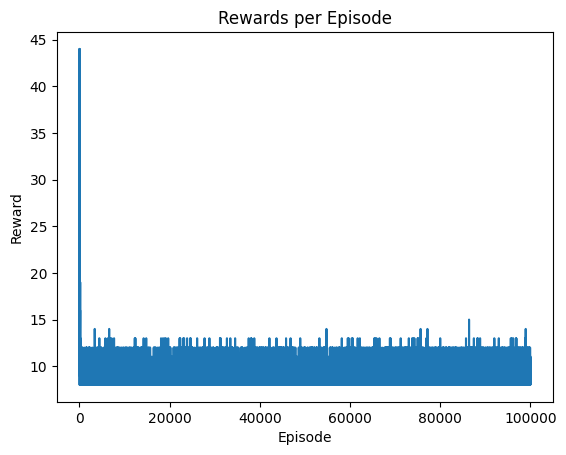

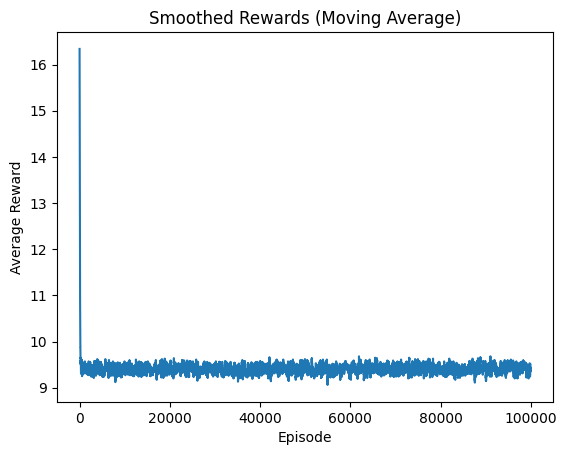

In [4]:
import matplotlib.pyplot as plt  # Imports Matplotlib's pyplot submodule as plt for plotting functions.

plt.plot(rewards)  # Plots raw rewards per episode.
plt.title('Rewards per Episode')  # Title.
plt.xlabel('Episode')  # X-label.
plt.ylabel('Reward')  # Y-label.
plt.show()  # Shows plot.

# Smoothed plot for trend (moving average over 100 episodes).
window = 100  # Window size for average.
smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')  # Computes moving average using convolution.
plt.plot(smoothed_rewards)  # Plots smoothed line.
plt.title('Smoothed Rewards (Moving Average)')  # Title for smoothed plot.
plt.xlabel('Episode')  # X-label.
plt.ylabel('Average Reward')  # Y-label.
plt.show()  # Shows smoothed plot (should show clear upward trend).

# Evaluation Explanation
Tests the trained agent on 100 episodes, computing average reward to measure performance (higher reward = better pole balancing, ~200-500 for good agent).

In [5]:
total_rewards = []  # List to store rewards from each test episode.
for _ in range(100):  # Loop over 100 test episodes to evaluate consistency.
    state, _ = env.reset()  # Resets environment for a new test episode.
    state = get_discrete_state(state)  # Discretizes the initial state.
    reward_sum = 0  # Initializes sum of rewards for the episode.
    done = False  # Flag for episode end.
    while not done:  # Loop until episode ends.
        action = np.argmax(q_table[state])  # Selects the best action from Q-table (greedy policy, no exploration in test).
        new_state, reward, done, _, _ = env.step(action)  # Takes action; gets new_state, reward, done.
        new_state = get_discrete_state(new_state)  # Discretizes new state.
        reward_sum += reward  # Accumulates reward (1 per step balanced).
        state = new_state  # Updates state.
    total_rewards.append(reward_sum)  # Appends episode reward to list.
print(np.mean(total_rewards))  # Prints average reward over 100 episodes (e.g., 200+ indicates good performance).

C:\Users\rober\AppData\Local\Temp\ipykernel_32220\2095976331.py:5: RuntimeWarning: invalid value encountered in divide
  return (state - low) / (high - low)  # Normalizes each dimension to 0-1.


9.53
